In [92]:
import numpy as np

In [102]:
import pandas as pd

df = pd.read_excel("sales_actual.xlsx", index_col= None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35058 entries, 0 to 35057
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   DW_Id                  35058 non-null  int64         
 1   Company                35058 non-null  object        
 2   Currency Code          35058 non-null  object        
 3   Customer Account       35058 non-null  object        
 4   Document Date          35058 non-null  datetime64[ns]
 5   Inventory Location ID  28548 non-null  object        
 6   Invoice Account        35058 non-null  object        
 7   Invoice Voucher        35057 non-null  object        
 8   Item ID                26599 non-null  object        
 9   RECID                  35058 non-null  int64         
 10  Salesperson Code       29308 non-null  float64       
 11  Sales Order No         29621 non-null  object        
 12  Sales Line No          35058 non-null  float64       
 13  S

In [103]:
df["Date"] = pd.to_datetime(df["Document Date"])

df_daily = (df
      .groupby("Date", as_index=False)
      .agg({
          "Sales": "sum",
          "Quantity": "sum",
          "Salesperson Code": "nunique"
      }))
df_daily.head()

,Date,Sales,Quantity,Salesperson Code
0,2022-02-28,71602564.67,0.0,0
1,2022-03-01,79261.88,2.0,1
2,2022-03-04,96153.75,2.0,1
3,2022-03-10,87168.48,5.0,0
4,2022-03-11,188031.19,15.0,2


In [104]:
df_daily = df_daily[1:].reset_index(drop=True)

In [105]:
df_daily['Sales'].describe()


count    1.010000e+03
mean     6.753266e+05
std      1.108896e+06
min     -1.531867e+06
25%      8.595173e+04
50%      2.768728e+05
75%      7.729028e+05
max      9.396374e+06
Name: Sales, dtype: float64

In [73]:
df_daily['Sales'].skew()

np.float64(3.56357107227922)

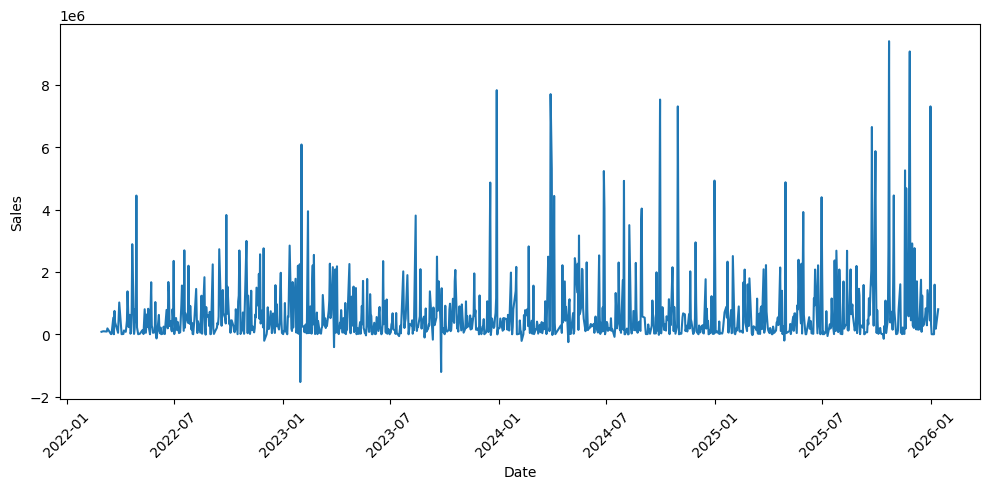

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_daily["Date"], df_daily["Sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [106]:
threshold = 0
(df_daily['Sales'] < threshold).mean()

np.float64(0.027722772277227723)

In [76]:
df_monthly = df_daily.resample('ME', on='Date')['Sales'].sum()

In [107]:
df_daily = df_daily.set_index("Date")
df_monthly = df_daily.resample("M").sum().reset_index()

C:\Users\AI TECH\AppData\Local\Temp\ipykernel_14896\208284598.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_daily.resample("M").sum().reset_index()


In [78]:
df_monthly.tail()

,Date,Sales,Quantity,Salesperson Code
42,2025-09-30,27233509.79,2743.0,84
43,2025-10-31,24913552.28,3902.0,95
44,2025-11-30,35335574.29,12249.0,79
45,2025-12-31,22848792.04,6141.5,85
46,2026-01-31,3251053.15,743.0,19


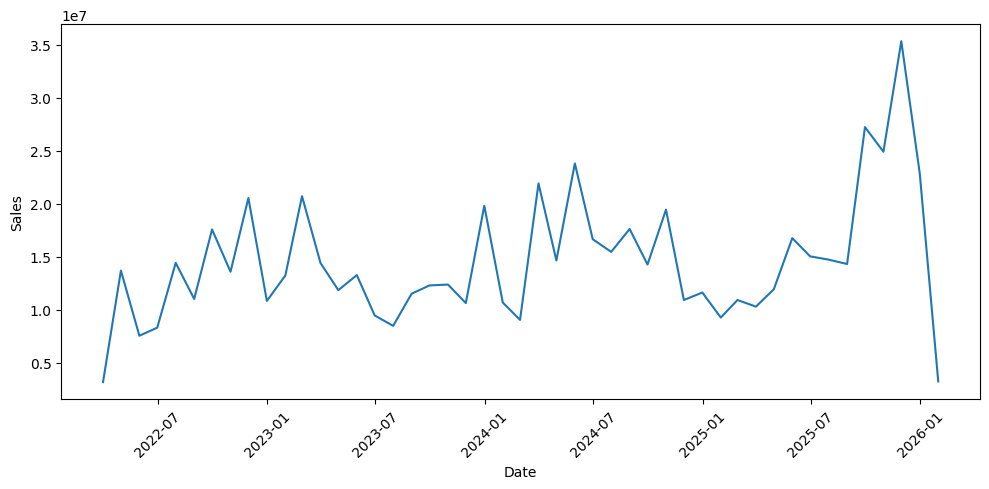

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(df_monthly["Date"], df_monthly["Sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

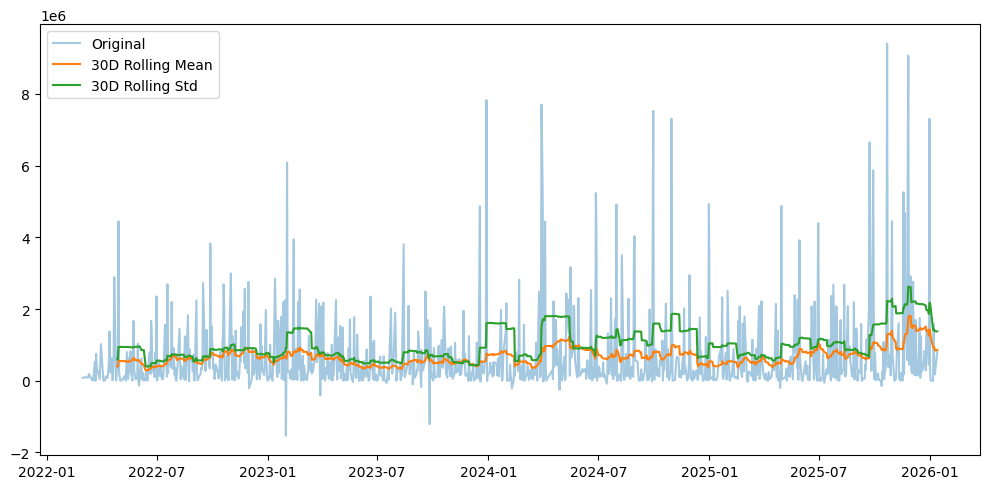

In [80]:
# assuming df_daily has Date index and Sales column
rolling_mean = df_daily["Sales"].rolling(window=30).mean()
rolling_std  = df_daily["Sales"].rolling(window=30).std()

plt.figure(figsize=(10,5))
plt.plot(df_daily.index, df_daily["Sales"], alpha=0.4, label="Original")
plt.plot(df_daily.index, rolling_mean, label="30D Rolling Mean")
plt.plot(df_daily.index, rolling_std, label="30D Rolling Std")
plt.legend()
plt.tight_layout()
plt.show()

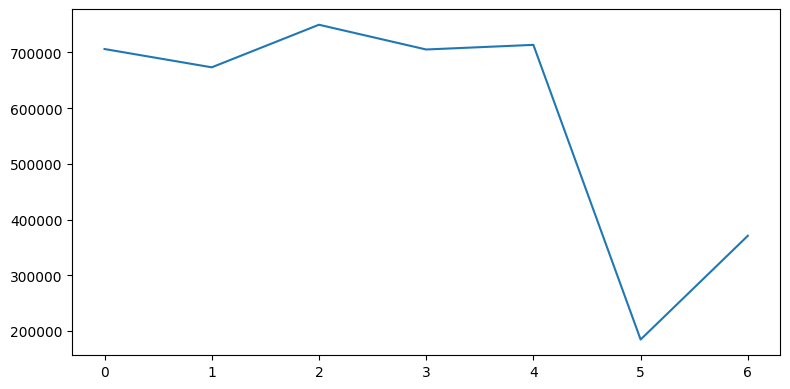

In [81]:
# extract weekday (0=Mon, 6=Sun)
df_daily["weekday"] = df_daily.index.dayofweek

weekday_avg = df_daily.groupby("weekday")["Sales"].mean()

plt.figure(figsize=(8,4))
plt.plot(weekday_avg.index, weekday_avg.values)
plt.xticks(range(7))
plt.tight_layout()
plt.show()

In [82]:
df_monthly["Date"] = pd.to_datetime(df_monthly["Date"])
df_monthly = df_monthly.set_index("Date")


df_monthly = df_monthly.iloc[:-1]

df_monthly.tail()

,Sales,Quantity,Salesperson Code
Date,,,
2025-08-31,14325016.91,1763.0,85
2025-09-30,27233509.79,2743.0,84
2025-10-31,24913552.28,3902.0,95
2025-11-30,35335574.29,12249.0,79
2025-12-31,22848792.04,6141.5,85


In [83]:
df_monthly = df_monthly.clip(lower=0)

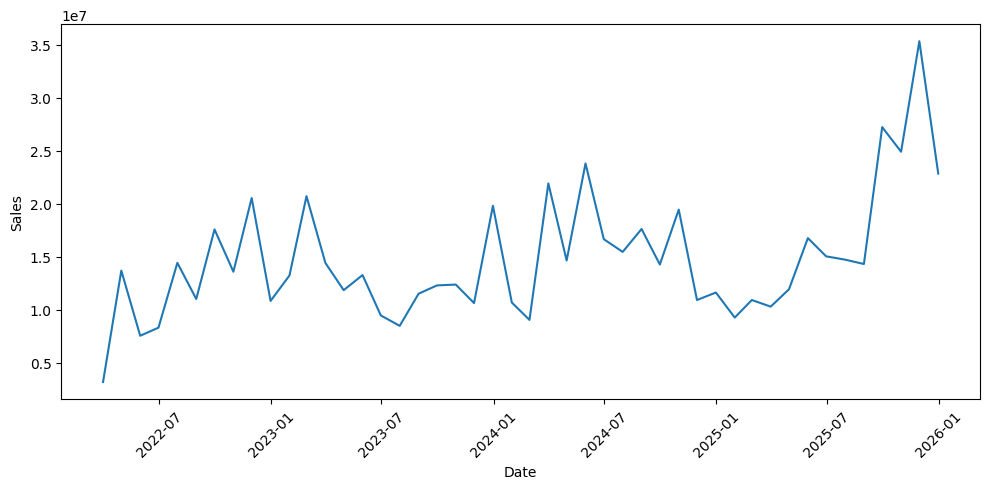

In [84]:
plt.figure(figsize=(10, 5))
plt.plot(df_monthly.index, df_monthly["Sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [108]:
df_daily = df_daily.iloc[:-7]

In [109]:
df_daily.tail()

,Sales,Quantity,Salesperson Code
Date,,,
2025-12-25,287388.14,78.0,5
2025-12-26,1415562.37,721.5,3
2025-12-29,780589.59,17.0,2
2025-12-30,442586.76,258.0,4
2025-12-31,7306454.87,736.0,18


In [110]:
df_daily["Sales"] = df_daily["Sales"].clip(lower=0)

In [111]:
df_daily["log_sales"] = np.log1p(df_daily["Sales"])
df_daily["weekday"] = df_daily.index.dayofweek
df_daily["month"] = df_daily.index.month
df_daily["is_month_end"] = df_daily.index.is_month_end.astype(int)
lags = [1, 7, 14, 30]

for lag in lags:
    df_daily[f"log_sales_lag_{lag}"] = df_daily["log_sales"].shift(lag)

df_daily = df_daily.dropna()

In [112]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 973 entries, 2022-04-28 to 2025-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales             973 non-null    float64
 1   Quantity          973 non-null    float64
 2   Salesperson Code  973 non-null    int64  
 3   log_sales         973 non-null    float64
 4   weekday           973 non-null    int32  
 5   month             973 non-null    int32  
 6   is_month_end      973 non-null    int64  
 7   log_sales_lag_1   973 non-null    float64
 8   log_sales_lag_7   973 non-null    float64
 9   log_sales_lag_14  973 non-null    float64
 10  log_sales_lag_30  973 non-null    float64
dtypes: float64(7), int32(2), int64(2)
memory usage: 83.6 KB


In [94]:
df_daily.tail()

,Sales,Quantity,Salesperson Code,weekday,log_sales,month,is_month_end,log_sales_lag_1,log_sales_lag_7,log_sales_lag_14,log_sales_lag_30
Date,,,,,,,,,,,
2025-12-25,287388.14,78.0,5,3,12.568592,12,0,13.488300,14.031203,14.344836,9.328212
2025-12-26,1415562.37,721.5,3,4,14.163038,12,0,12.568592,12.476159,13.260966,15.474725
2025-12-29,780589.59,17.0,2,0,13.567806,12,0,14.163038,12.542736,11.889054,12.124489
2025-12-30,442586.76,258.0,4,1,13.000394,12,0,13.567806,12.654720,12.452311,15.359236
2025-12-31,7306454.87,736.0,18,2,15.804269,12,1,13.000394,13.281716,11.959949,14.652204


In [95]:
split = int(len(df_daily) * 0.8)

train = df_daily.iloc[:split]
test  = df_daily.iloc[split:]

X_train = train.drop(columns=["Sales", "log_sales"])
y_train = train["log_sales"]

X_test  = test.drop(columns=["Sales", "log_sales"])
y_test  = test["log_sales"]

In [96]:
from sklearn.metrics import mean_absolute_error
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

In [97]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)
lgb_pred_orig = np.expm1(lgb_pred)
y_test_orig   = np.expm1(y_test)
print("LGB MAE:", mean_absolute_error(y_test_orig, lgb_pred_orig))
print("LGB SMAPE:", smape(y_test_orig, lgb_pred_orig))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001951 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1298
[LightGBM] [Info] Number of data points in the train set: 778, number of used features: 9
[LightGBM] [Info] Start training from score 11.913398
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [98]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

y_test_orig   = np.expm1(y_test)
xgb_pred_orig = np.expm1(xgb_pred)

print("XGB MAE:", mean_absolute_error(y_test_orig, xgb_pred_orig))
print("XGB SMAPE:", smape(y_test_orig, xgb_pred_orig))

XGB MAE: 719202.8196140756
XGB SMAPE: 107.92938955875027


Iteration 2 

In [113]:
df2 = df_daily.copy()

# Ensure chronological order
df2 = df2.sort_index()


df2["roll_mean_7"]  = df2["log_sales"].shift(1).rolling(7).mean()
df2["roll_std_7"]   = df2["log_sales"].shift(1).rolling(7).std()

df2["roll_mean_30"] = df2["log_sales"].shift(1).rolling(30).mean()
df2["roll_std_30"]  = df2["log_sales"].shift(1).rolling(30).std()

df2["trend_7"] = df2["log_sales"].shift(1) - df2["log_sales_lag_7"]
df2 = df2.dropna()

In [114]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 943 entries, 2022-06-10 to 2025-12-31
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales             943 non-null    float64
 1   Quantity          943 non-null    float64
 2   Salesperson Code  943 non-null    int64  
 3   log_sales         943 non-null    float64
 4   weekday           943 non-null    int32  
 5   month             943 non-null    int32  
 6   is_month_end      943 non-null    int64  
 7   log_sales_lag_1   943 non-null    float64
 8   log_sales_lag_7   943 non-null    float64
 9   log_sales_lag_14  943 non-null    float64
 10  log_sales_lag_30  943 non-null    float64
 11  roll_mean_7       943 non-null    float64
 12  roll_std_7        943 non-null    float64
 13  roll_mean_30      943 non-null    float64
 14  roll_std_30       943 non-null    float64
 15  trend_7           943 non-null    float64
dtypes: float64(12), int32(2),

In [121]:
split = int(len(df2) * 0.8)

train = df2.iloc[:split]
test  = df2.iloc[split:]

features = [
    "weekday",
    "month",
    "is_month_end",
    "Salesperson Code",
    "Quantity",
    "log_sales_lag_1",
    "log_sales_lag_7",
    "log_sales_lag_14",
    "log_sales_lag_30",
    "roll_mean_7",
    "roll_std_7",
    "roll_mean_30",
    "roll_std_30",
    "trend_7"
]

X_train = train[features]
y_train = train["log_sales"]

X_test  = test[features]
y_test  = test["log_sales"]

In [122]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)

lgb.fit(X_train, y_train)

pred_log = lgb.predict(X_test)

pred = np.expm1(pred_log)
actual = np.expm1(y_test)

print("MAE:", mean_absolute_error(actual, pred))
print("LGB SMAPE:", smape(actual, pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2520
[LightGBM] [Info] Number of data points in the train set: 754, number of used features: 14
[LightGBM] [Info] Start training from score 11.925068
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [123]:
df2["Sales"].autocorr(lag=1)


np.float64(0.11433866182593476)

In [124]:
df2["Sales"].autocorr(lag=7)


np.float64(0.02231203235678325)

In [125]:
df2["Sales"].autocorr(lag=30)

np.float64(0.003150416548479731)

In [126]:
test_results = test.copy()

test_results["actual"] = actual
test_results["pred"] = pred

monthly_actual = test_results["actual"].resample("M").sum()
monthly_pred   = test_results["pred"].resample("M").sum()



print("Monthly MAE:", mean_absolute_error(monthly_actual, monthly_pred))
print("Monthly SMAPE:", smape(monthly_actual, monthly_pred))

Monthly MAE: 11747272.711665941
Monthly SMAPE: 75.8229636603628


C:\Users\AI TECH\AppData\Local\Temp\ipykernel_14896\4050514848.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_actual = test_results["actual"].resample("M").sum()
C:\Users\AI TECH\AppData\Local\Temp\ipykernel_14896\4050514848.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pred   = test_results["pred"].resample("M").sum()
